In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import glv

# ==========================================
# Simulation Setup: Large Scale
# ==========================================
N = 10_000    # 10k species
C = 8.0       # Average degree
sigma = 0.5   # Heterogeneity of the interactions
gamma = 0.0   # No correlation between interaction pairs

np.random.seed(42)

# 1. Generate Exponential Degree Sequence
degree_sequence = np.maximum(np.random.exponential(scale=C, size=N).astype(int), 1)
if np.sum(degree_sequence) % 2 != 0:
    degree_sequence[0] += 1

# 2. Build Interaction Matrix at mu_c
# g = k/C ~ Exp(1) for exponential degree distribution
nu_pdf = lambda g: np.exp(-g)
mu_c = glv.compute_mu_c(sigma=sigma, gamma=gamma, nu_pdf=nu_pdf)
print(f"Calculated Critical Interaction Strength (mu_c): {mu_c:.4f}")

W_sparse = glv.generate_matrix(degree_sequence, C, mu=mu_c, sigma=sigma)

# Find the Max Degree Hub
max_degree_node = np.argmax(degree_sequence)
print(f"Network built. Highest degree hub is Node {max_degree_node} with k={degree_sequence[max_degree_node]:.0f}")

# ==========================================
# Initialize and Integrate
# ==========================================
x_initial = np.random.uniform(0.1, 1.0, N)
M_0 = np.sum(x_initial)
y_0 = x_initial / M_0
t_0 = 0.0

initial_state = np.concatenate((y_0, [M_0], [t_0]))

tau_span = (0, 5*1e4)
tau_eval = np.linspace(tau_span[0], tau_span[1], 1000)

print(f"Integrating N={N} rescaled ODEs (this might take a few seconds)...")
solution = solve_ivp(
    fun=glv.rescaled_glv_sparse,
    t_span=tau_span,
    y0=initial_state,
    t_eval=tau_eval,
    args=(N, W_sparse),
    method='RK45'
)
print("Integration complete!")

# ==========================================
# Trajectory Sampling Logic
# ==========================================
all_nodes = np.arange(N)
remaining_nodes = np.delete(all_nodes, max_degree_node)
sample_size = 9999
sampled_nodes = np.random.choice(remaining_nodes, size=sample_size, replace=False)
plot_indices = np.append(sampled_nodes, max_degree_node)

y_trajectories = solution.y[plot_indices, :]
M_trajectory = solution.y[N, :]
t_trajectory = solution.y[N+1, :]
x_trajectories = y_trajectories * M_trajectory

hub_plot_idx = sample_size

# ==========================================
# Plotting
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, original_node_id in enumerate(plot_indices):
    if idx == hub_plot_idx:
        axes[0].plot(solution.t, y_trajectories[idx, :], lw=2.5, color='red', zorder=10,
                     label=f'Max Degree Hub (k={degree_sequence[original_node_id]:.0f})')
    else:
        axes[0].plot(solution.t, y_trajectories[idx, :], lw=0.8, color='gray', alpha=0.3)

axes[0].set_title(f"Sampled Fractions (100 of {N}) vs $\\tau$")
axes[0].set_xlabel("Stretched Time $\\tau$")
axes[0].set_ylabel("Relative Fraction $y_i$")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for idx, original_node_id in enumerate(plot_indices):
    if idx == hub_plot_idx:
        axes[1].plot(t_trajectory, x_trajectories[idx, :], lw=2.5, color='red', zorder=10)
    else:
        axes[1].plot(t_trajectory, x_trajectories[idx, :], lw=0.8, color='gray', alpha=0.3)

axes[1].set_title(f"Sampled Absolute Abundances ({sample_size+1} of {N}) vs $t$")
axes[1].set_xlabel("Physical Time $t$ (Singularity Asymptote)")
axes[1].set_ylabel("Absolute Abundance $x_i$")
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"The finite-time singularity occurs exactly at t* ≈ {t_trajectory[-1]:.4f}")

In [1]:
N = 10_000    
C = 8.0       
sigma = 0.5   

In [3]:
degree_sequence = np.maximum(np.random.exponential(scale=C, size=N).astype(int), 1)
if np.sum(degree_sequence) % 2 != 0:
    degree_sequence[0] += 1

mu_c = glv.compute_mu_c(degree_sequence, C)
print(f"Calculated Critical Interaction Strength (mu_c): {mu_c:.4f}")

W_sparse = glv.generate_matrix(degree_sequence, C, mu=mu_c, sigma=sigma)

# Find the Max Degree Hub
degrees = np.array(W_sparse.sum(axis=1)).flatten()
max_degree_node = np.argmax(np.abs(degrees))
print(f"Network built. Highest degree hub is Node {max_degree_node} with k={degree_sequence[max_degree_node]:.0f}")

# ==========================================
# Initialize and Integrate
# ==========================================
x_initial = np.random.uniform(0.1, 1.0, N)
M_0 = np.sum(x_initial)
y_0 = x_initial / M_0
t_0 = 0.0

initial_state = np.concatenate((y_0, [M_0], [t_0]))

tau_span = (0, 5*1e4)
tau_eval = np.linspace(tau_span[0], tau_span[1], 1000)

solution = solve_ivp(
    fun=glv.rescaled_glv_sparse,
    t_span=tau_span,
    y0=initial_state,
    t_eval=tau_eval,
    args=(N, W_sparse),
    method='RK45'
)

Calculated Critical Interaction Strength (mu_c): 0.5348
Network built. Highest degree hub is Node 3354 with k=64


In [ ]:
all_nodes = np.arange(N)
remaining_nodes = np.delete(all_nodes, max_degree_node)
sample_size = 9999
sampled_nodes = np.random.choice(remaining_nodes, size=sample_size, replace=False)
plot_indices = np.append(sampled_nodes, max_degree_node)

y_trajectories = solution.y[plot_indices, :]
M_trajectory = solution.y[N, :]
t_trajectory = solution.y[N+1, :]
x_trajectories = y_trajectories * M_trajectory

hub_plot_idx = sample_size

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, original_node_id in enumerate(plot_indices):
    if idx == hub_plot_idx:
        axes[0].plot(solution.t, y_trajectories[idx, :], lw=2.5, color='red', zorder=10,
                     label=f'Max Degree Hub (k={degree_sequence[original_node_id]:.0f})')
    else:
        axes[0].plot(solution.t, y_trajectories[idx, :], lw=0.8, color='gray', alpha=0.3)

axes[0].set_title(f"Sampled Fractions (100 of {N}) vs $\\tau$")
axes[0].set_xlabel("Stretched Time $\\tau$")
axes[0].set_ylabel("Relative Fraction $y_i$")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for idx, original_node_id in enumerate(plot_indices):
    if idx == hub_plot_idx:
        axes[1].plot(t_trajectory, x_trajectories[idx, :], lw=2.5, color='red', zorder=10)
    else:
        axes[1].plot(t_trajectory, x_trajectories[idx, :], lw=0.8, color='gray', alpha=0.3)

axes[1].set_title(f"Sampled Absolute Abundances ({sample_size+1} of {N}) vs $t$")
axes[1].set_xlabel("Physical Time $t$ (Singularity Asymptote)")
axes[1].set_ylabel("Absolute Abundance $x_i$")
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"The finite-time singularity occurs exactly at t* ≈ {t_trajectory[-1]:.4f}")

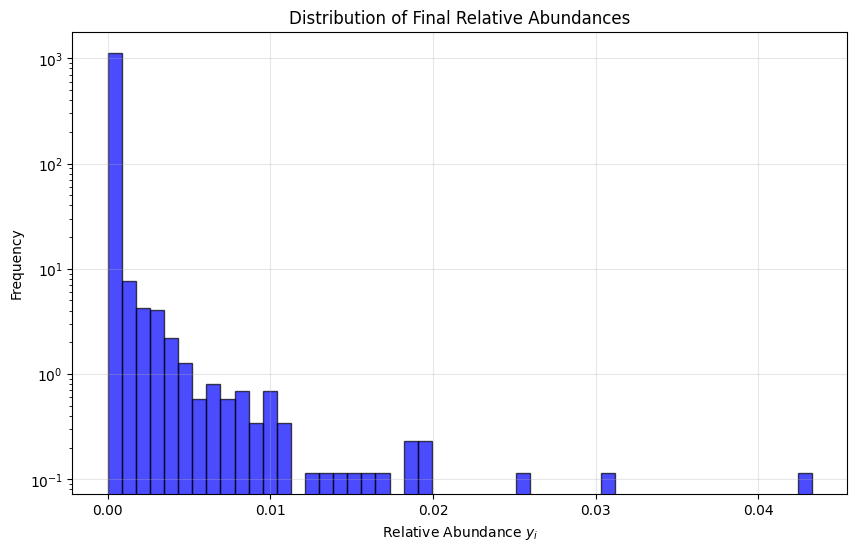

In [2]:
# ==========================================
# Plot Distribution of Final Relative Abundances
# ==========================================
final_y = y_trajectories[:, -1]

plt.figure(figsize=(10, 6))
plt.hist(final_y, bins=50, alpha=0.7, color='blue', edgecolor='black',density=True)
plt.title("Distribution of Final Relative Abundances")
plt.xlabel("Relative Abundance $y_i$")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()